## Logistic Regression (Gradient Descent)

`Logistic Regression` trained using `Gradient Descent` learns model parameters
step by step by **reducing prediction error**.
This view focuses on **how the model learns**, not just how it predicts.

---

### What It Is

Logistic Regression (Gradient Descent):
- Uses gradient descent to update weights
- Learns from prediction errors
- Improves predictions over multiple iterations
- Minimizes classification loss gradually

---

### Why It Is Used

This approach is used because:
- Closed-form solutions are not practical
- Gradient descent works for large datasets
- It generalizes well to complex models
- It is the foundation of deep learning

---

### Where It Is Used

Gradient-descent-based Logistic Regression is used in:
- Binary classification problems
- Large-scale machine learning
- Online and incremental learning
- Neural network training foundations

---

### When It Performs Well

It performs well when:
- Data is scaled properly
- Learning rate is chosen correctly
- Dataset is medium to large
- Loss function is smooth

---

### When It Performs Poorly

It performs poorly when:
- Learning rate is poorly chosen
- Data is not normalized
- Dataset is very small
- Loss surface is noisy

---

### Advantages

- Scales well to large datasets
- Flexible and efficient
- Core method behind many ML models
- Works with different optimizers

---

### Limitations

- Sensitive to learning rate
- Requires multiple iterations
- Can converge slowly
- Needs careful tuning

---

### Key Takeaways

- Gradient Descent trains Logistic Regression iteratively
- Learns by reducing error step by step
- Core concept for modern ML and DL
- Requires proper scaling and tuning


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

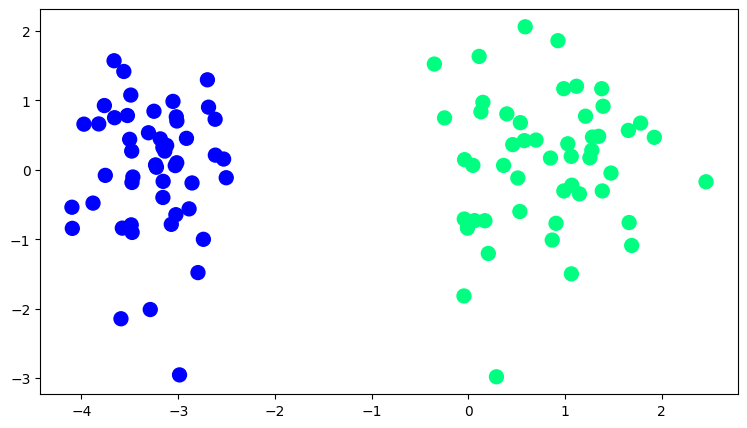

In [5]:
plt.figure(figsize=(9,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [8]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

C:\Users\Msi Laptop\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [9]:
print(lor.coef_)
print(lor.intercept_)

[[4.81825421 0.21398335]]
[5.79537708]


In [10]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [11]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [12]:
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
        

In [13]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [14]:
coef_,intercept_ = gd(X,y)

In [15]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [16]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

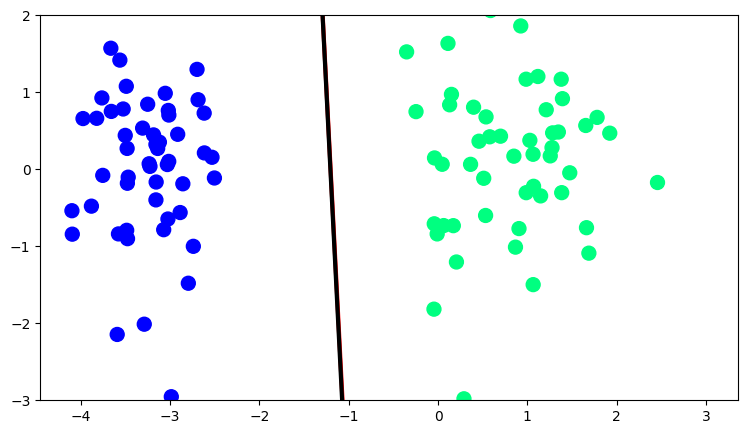

In [18]:
plt.figure(figsize=(9,5))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)